In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
def fc_layer(in_size, out_size, norm_layer):
    """Return a stack of linear->norm->sigmoid layers"""
    return nn.Sequential(
        nn.Linear(in_size, out_size), norm_layer(out_size), nn.Sigmoid()
    )


class Net(nn.Module):
    """Define a network that has num_layers of linear->norm->sigmoid transformations"""

    def __init__(
        self,
        in_size=28 * 28,
        hidden_size=128,
        out_size=10,
        num_layers=3,
        batchnorm=False,
    ):
        super().__init__()
        if batchnorm is False:
            norm_layer = nn.Identity
        else:
            norm_layer = nn.BatchNorm1d

        layers = []
        layers.append(fc_layer(in_size, hidden_size, norm_layer))

        for i in range(num_layers - 1):
            layers.append(fc_layer(hidden_size, hidden_size, norm_layer))

        layers.append(nn.Linear(hidden_size, out_size))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = torch.flatten(x, 1)
        return self.layers(x)

In [3]:
# set up dummy data
x = torch.randn(10, 28, 28)
y = torch.randint(10, (10,))

# init model
model_bn = Net(batchnorm=True, num_layers=3)
model_nobn = Net(batchnorm=False, num_layers=3)

model_bn.train()
model_nobn.train()

optimizer_bn = optim.SGD(model_bn.parameters(), lr=0.01, momentum=0.9)
optimizer_nobn = optim.SGD(model_nobn.parameters(), lr=0.01, momentum=0.9)

In [4]:
print(model_bn.layers[0])
print(model_nobn.layers[0])

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): Sigmoid()
)
Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): Identity()
  (2): Sigmoid()
)


In [5]:
# note that wrapper functions are used for Python closure
# so that we can pass arguments.


def hook_forward(module_name, grads, hook_backward):
    def hook(module, args, output):
        """Forward pass hook which attaches backward pass hooks to intermediate tensors"""
        output.register_hook(hook_backward(module_name, grads))

    return hook


def hook_backward(module_name, grads):
    def hook(grad):
        """Backward pass hook which appends gradients"""
        grads.append((module_name, grad))

    return hook


def get_all_layers(model, hook_forward, hook_backward):
    """Register forward pass hook (which registers a backward hook) to model outputs

    Returns:
        - layers: a dict with keys as layer/module and values as layer/module names
                  e.g. layers[nn.Conv2d] = layer1.0.conv1
        - grads: a list of tuples with module name and tensor output gradient
                 e.g. grads[0] == (layer1.0.conv1, tensor.Torch(...))
    """
    layers = dict()
    grads = []
    for name, layer in model.named_modules():
        # skip Sequential and/or wrapper modules
        if any(layer.children()) is False:
            layers[layer] = name
            layer.register_forward_hook(hook_forward(name, grads, hook_backward))
    return layers, grads


# register hooks
layers_bn, grads_bn = get_all_layers(model_bn, hook_forward, hook_backward)
layers_nobn, grads_nobn = get_all_layers(model_nobn, hook_forward, hook_backward)

In [6]:
epochs = 10

for epoch in range(epochs):

    # important to clear, because we append to
    # outputs everytime we do a forward pass
    grads_bn.clear()
    grads_nobn.clear()

    optimizer_bn.zero_grad()
    optimizer_nobn.zero_grad()

    y_pred_bn = model_bn(x)
    y_pred_nobn = model_nobn(x)

    loss_bn = F.cross_entropy(y_pred_bn, y)
    loss_nobn = F.cross_entropy(y_pred_nobn, y)

    loss_bn.backward()
    loss_nobn.backward()

    optimizer_bn.step()
    optimizer_nobn.step()

In [7]:
def get_grads(grads):
    layer_idx = []
    avg_grads = []
    for idx, (name, grad) in enumerate(grads):
        if grad is not None:
            avg_grad = grad.abs().mean()
            avg_grads.append(avg_grad)
            # idx is backwards since we appended in backward pass
            layer_idx.append(len(grads) - 1 - idx)
    return layer_idx, avg_grads


layer_idx_bn, avg_grads_bn = get_grads(grads_bn)
layer_idx_nobn, avg_grads_nobn = get_grads(grads_nobn)

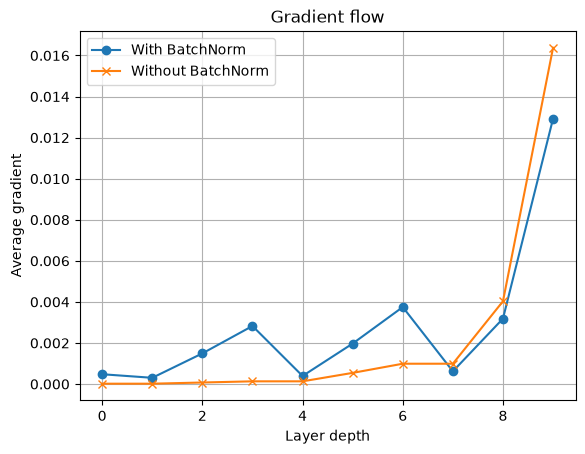

In [8]:
fig, ax = plt.subplots()
ax.plot(layer_idx_bn, avg_grads_bn, label="With BatchNorm", marker="o")
ax.plot(layer_idx_nobn, avg_grads_nobn, label="Without BatchNorm", marker="x")
ax.set_xlabel("Layer depth")
ax.set_ylabel("Average gradient")
ax.set_title("Gradient flow")
ax.grid(True)
ax.legend()
plt.show()